In [1]:
# Data manipulation and analysis libraries
import pandas as pd
pd.set_option('display.max_columns', None)  # Ensure all columns are visible when displaying DataFrames

# Numerical computing library
import numpy as np

# Data visualization libraries
import seaborn as sns
import matplotlib.pyplot as plt

# Environment and warning management
import warnings
warnings.filterwarnings('ignore')  # Suppress clean-up or deprecation warnings to keep the output clean

In [2]:
# Load the cleaned and merged dataset for statistical analysis and visualization
df_clean = pd.read_csv("../data/Customer_Flight_Loyalty_Clean.csv")

In [3]:
df_clean.sample(5)

,Loyalty Number,Year,Month,Flights Booked,Flights with Companions,Total Flights,Distance,Points Accumulated,Country,Province,City,Postal Code,Gender,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month,Customer Active
123077,391402,2017,8,15,5,20,3840,384.0,Canada,Ontario,Toronto,P5S 6R4,Male,Bachelor,69765.000000,Single,Aurora,5598.01,Standard,2017,6,True
293110,487228,2018,6,7,0,7,4032,403.0,Canada,Ontario,Kingston,M9K 2P4,Male,College,79720.873238,Divorced,Aurora,8273.11,Standard,2018,1,True
148470,845945,2017,9,8,0,8,2840,284.0,Canada,British Columbia,Vancouver,V6E 3Z3,Female,Bachelor,98851.000000,Divorced,Star,4571.51,Standard,2014,1,True
290627,739704,2018,10,0,0,0,0,0.0,Canada,British Columbia,Vancouver,V6E 3Z3,Male,Bachelor,74450.000000,Married,Star,2609.83,Standard,2014,2,False
203425,190052,2018,1,0,0,0,0,0.0,Canada,British Columbia,Dawson Creek,U5I 4F1,Male,Bachelor,65094.000000,Married,Nova,11463.99,Standard,2013,10,True


## 01. Numerical Variable Analysis

### Descriptive Statistics: 

- Calculate summary statistics (mean, median, mode, standard deviation, etc.) for the relevant numerical variables.

In [4]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 403760 entries, 0 to 403759
Data columns (total 22 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Loyalty Number           403760 non-null  int64  
 1   Year                     403760 non-null  int64  
 2   Month                    403760 non-null  int64  
 3   Flights Booked           403760 non-null  int64  
 4   Flights with Companions  403760 non-null  int64  
 5   Total Flights            403760 non-null  int64  
 6   Distance                 403760 non-null  int64  
 7   Points Accumulated       403760 non-null  float64
 8   Country                  403760 non-null  str    
 9   Province                 403760 non-null  str    
 10  City                     403760 non-null  str    
 11  Postal Code              403760 non-null  str    
 12  Gender                   403760 non-null  str    
 13  Education                403760 non-null  str    
 14  Salary         

In [5]:
# Select the relevant numerical variables for statistical analysis
# Year/Month-type column are excluded because they act as grouping variables rather than numerical distributions
# Loyalty Number is excluded as it is a customer identifier, not a metric.

numerical_cols_flights = ['Flights Booked', 'Flights with Companions', 'Total Flights', 'Distance', 'Points Accumulated']

sumary_df_clean = round(df_clean[numerical_cols_flights].describe(), 2).T
sumary_df_clean

,count,mean,std,min,25%,50%,75%,max
Flights Booked,403760.0,4.13,5.23,0.0,0.0,1.0,8.0,21.0
Flights with Companions,403760.0,1.04,2.08,0.0,0.0,0.0,1.0,11.0
Total Flights,403760.0,5.17,6.53,0.0,0.0,1.0,10.0,32.0
Distance,403760.0,1214.46,1434.10,0.0,0.0,525.0,2342.0,6293.0
Points Accumulated,403760.0,124.26,146.70,0.0,0.0,53.0,240.0,676.5


In [6]:
# Calculate the mode for the relevant numerical variables
flights_modes = df_clean[numerical_cols_flights].mode().iloc[0]
flights_modes

Flights Booked             0.0
Flights with Companions    0.0
Total Flights              0.0
Distance                   0.0
Points Accumulated         0.0
Name: 0, dtype: float64

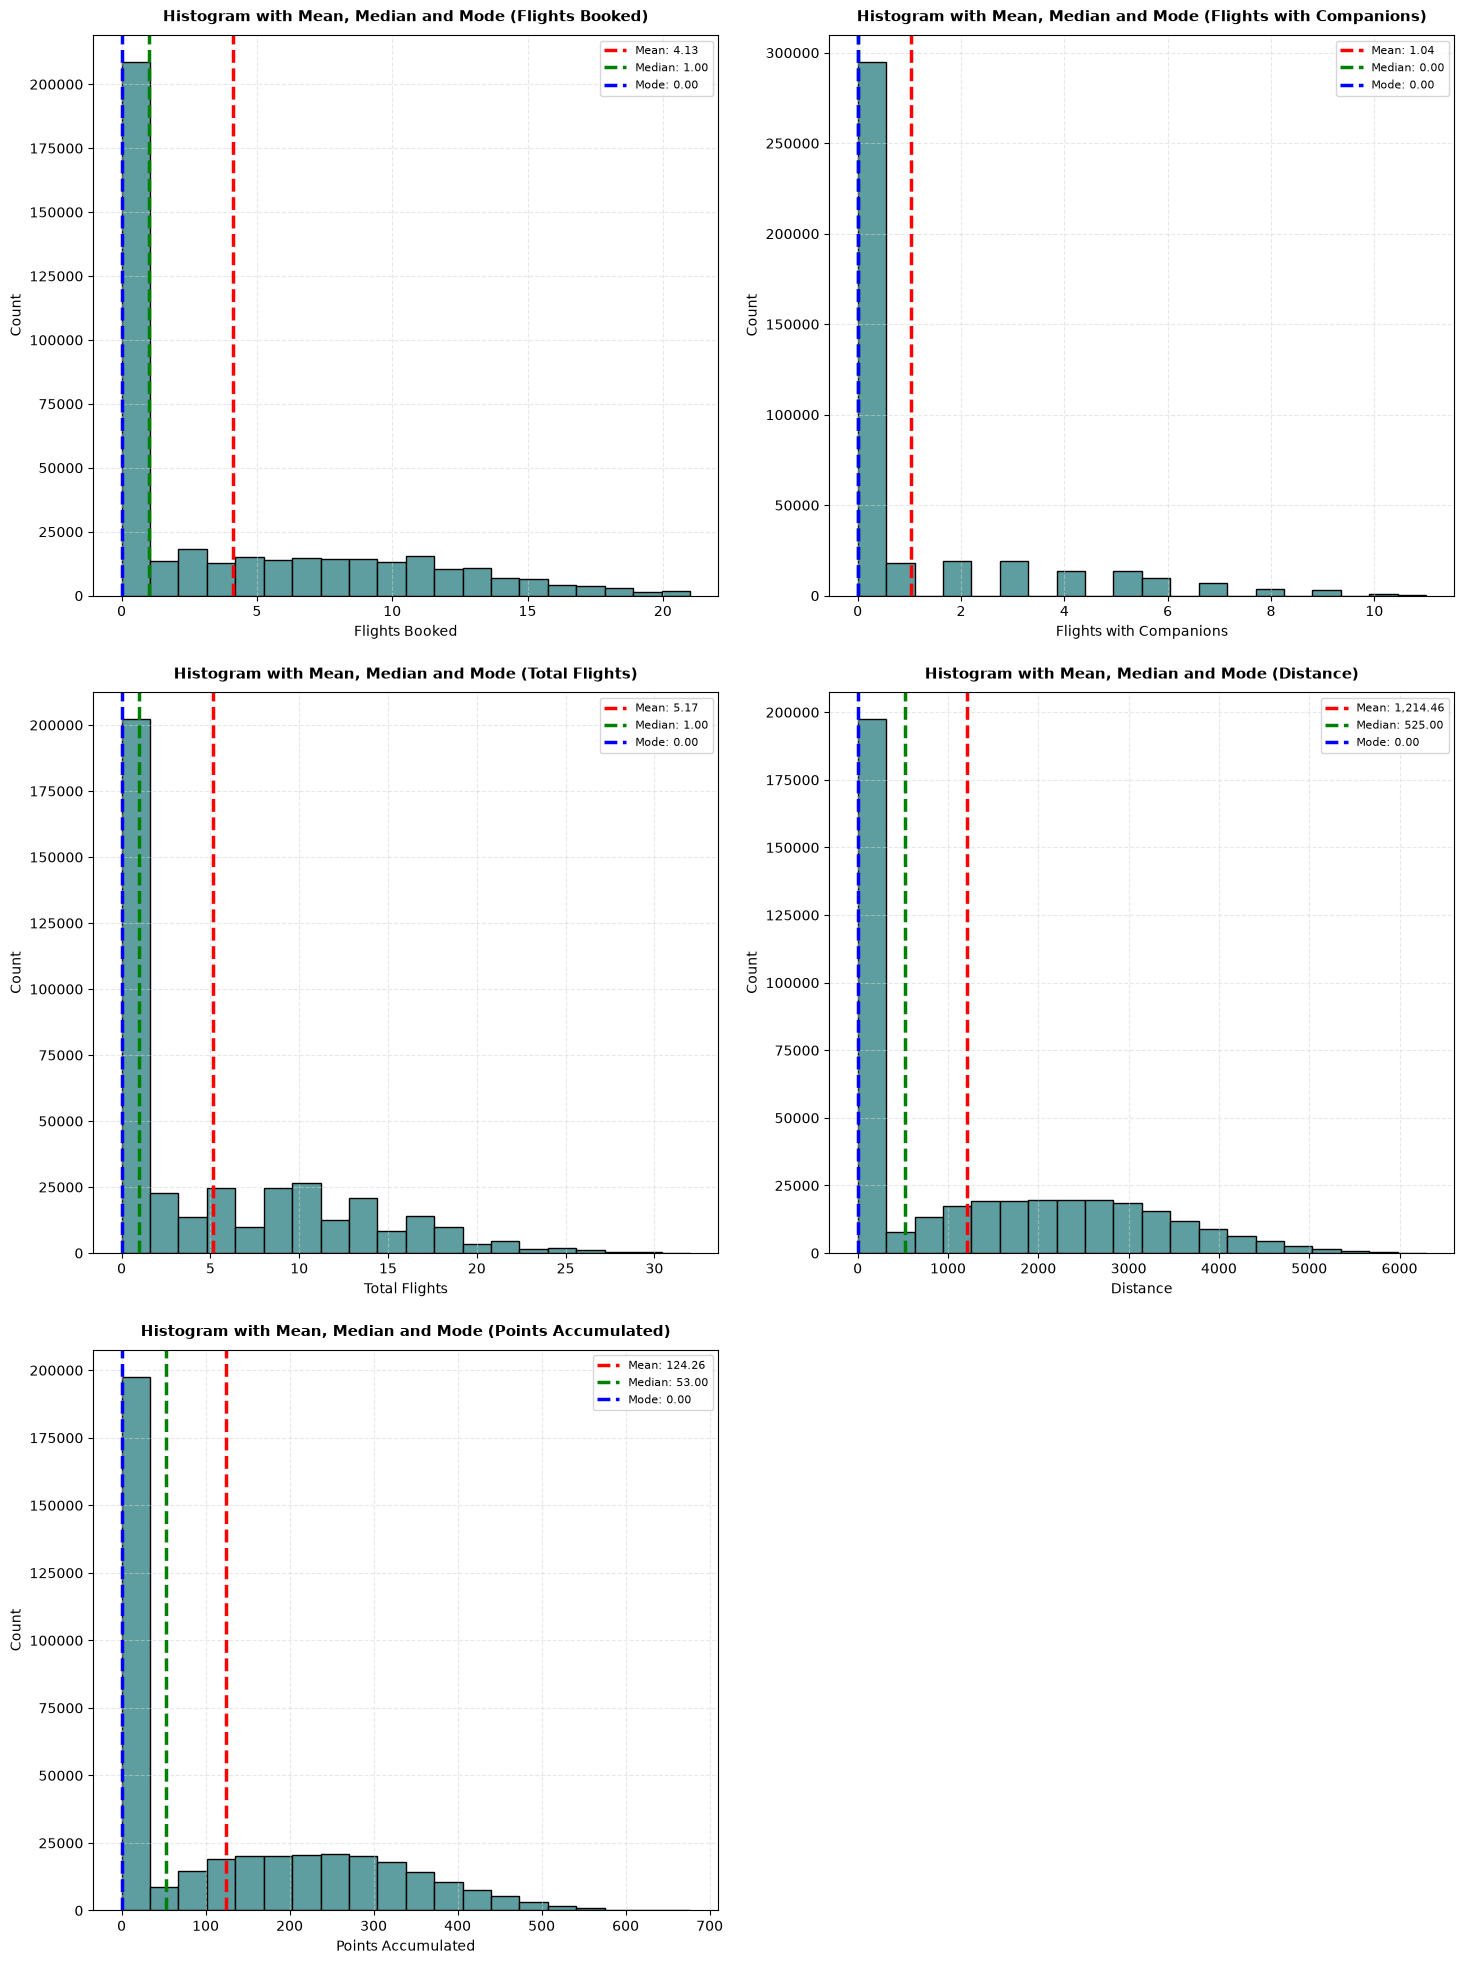

In [7]:
# Plot all histograms and customize axes labels dynamically
axes = df_clean[numerical_cols_flights].hist(bins=20, color= 'cadetblue', edgecolor='black', grid= False, figsize=(15, 20))

# Loop through each individual subplot to add labels
for ax in axes.flatten():

    col_name = ax.get_title()
    if col_name: 
        # Extract statistical metrics from pre-calculated variables
        mean = sumary_df_clean.loc[col_name, 'mean']
        median = sumary_df_clean.loc[col_name, '50%']
        mode_data = flights_modes[col_name]
        mode = mode_data.iloc[0] if hasattr(mode_data, 'iloc') else mode_data

        # Add vertical lines for Mean, Median, and Mode
        ax.axvline(mean, color='red', linestyle='--', linewidth=2.5, label=f'Mean: {mean:,.2f}')
        ax.axvline(median, color='green', linestyle='--', linewidth=2.5, label=f'Median: {median:,.2f}')
        ax.axvline(mode, color='blue', linestyle='--', linewidth=2.5, label=f'Mode: {mode:,.2f}')
        
        # Customize axes labels and set the requested descriptive title
        ax.set_title(f"Histogram with Mean, Median and Mode ({col_name})", fontsize=11, pad=10, fontweight='bold')
        ax.set_xlabel(col_name)
        ax.set_ylabel("Count")

        # Display the legend in a clean position
        ax.legend(loc='upper right', fontsize=8, framealpha=0.8)

        ax.grid(True, linestyle='--', alpha=0.5, color='lightgray', zorder=0) # Add a subtle, light gray, dashed grid behind the bars

# Adjust spacing
plt.tight_layout(pad=2.0)
# Save the complete figure

plt.savefig("../figures/02_Statistical_Analysis_Figures/histo_flights.png")

***Initial Insights & Real-World Meaning:***

* **Flights Booked & Flights with Companions:** 
    - `Flights Booked` has a mean of 4.13 but a high standard deviation of 5.23, with half of the records (up to the 50% percentile) showing 1 or fewer flights. This gap between the median and the maximum value of 21 suggests the presence of high-value outliers, that indicates a specific profile: **frequent business travelers** who fly constantly.
    - `Flights with Companions`, the maximum is 11, while the mean is only 1.04. The value 0 is highly recurrent up to the 50% percentile, showing that **the vast majority of customers travel alone**.

* **Total Flights:** As the combination of both metrics, it reflects a similar behavior. The first two quartiles hold a value of 1.00, and the maximum spikes to 32, which strongly points to outliers in flight frequency. This confirms that **the airline's baseline activity relies heavily on a small group of highly active users** who push the standard deviation up to 6.53.

* **Distance & Points Accumulated:** Both variables behave almost identically because points depend directly on distance. Both present a very high variability (their standard deviations are larger than their means). This explains why the first 25% of the data is 0, proving that **in any given month, a significant portion of program members do not fly at all**, while the maximum values stretch far out to 6,293 units in distance and 676.50 in points, indicating clear outliers from heavy travelers that make **long-haul international flights**


* **Mode Analysis:** Looking at the most frequent values (mode), we can confirm that for any given month, the most common scenario for a customer is to have `0` flights booked, `0` flights with companions, `0` total flights, `0` distance flown, and `0` points accumulated. This aligns with our previous observation that a large portion of the loyalty program members remain **inactive during many months of the year**. This pattern is also reflected in the displayed histograms.

**Methodological Note:** 

Since the dataset contains monthly records, client-specific variables like `Salary` and `CLV` are repeated across months. To ensure accurate demographic analysis without inflation, a sub-analysis of unique customers was conducted, confirming that the overall income and valuation averages remain stable.

In [8]:
# Group by customer to analyze unique profile variables (Salary and CLV) without monthly repetition
df_unique_customers = df_clean.drop_duplicates(subset=['Loyalty Number'])
numerical_cols_customers = ['Salary', 'CLV']
sumary_df_customers = round(df_unique_customers[numerical_cols_customers].describe(),2).T
sumary_df_customers

,count,mean,std,min,25%,50%,75%,max
Salary,16737.0,79362.93,30032.44,9081.00,63899.00,78879.00,82940.00,407228.00
CLV,16737.0,7988.90,6860.98,1898.01,3980.84,5780.18,8940.58,83325.38


In [9]:
# Calculate the mode for the relevant numerical variables
customers_modes= df_unique_customers[numerical_cols_customers].mode().iloc[0]
customers_modes

Salary    101933.00
CLV         8564.77
Name: 0, dtype: float64

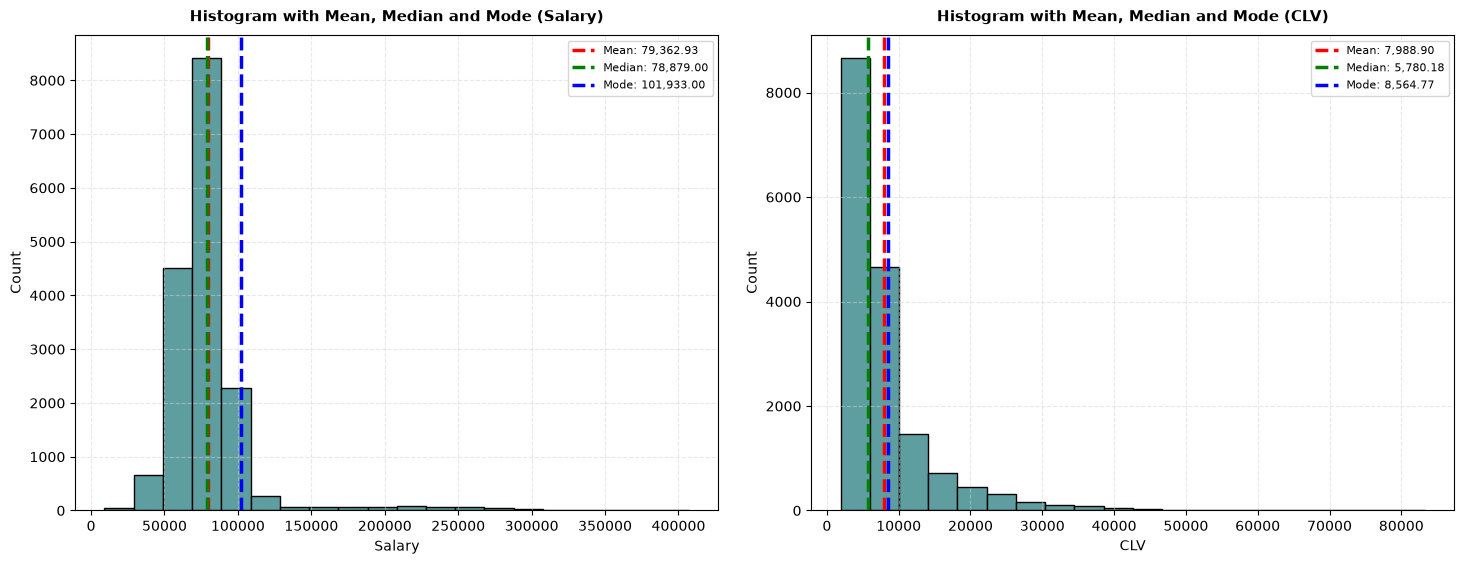

In [10]:
# Plot all histograms and customize axes labels dynamically
axes = df_unique_customers[numerical_cols_customers].hist(bins=20, color='cadetblue', edgecolor='black', grid= False, figsize=(15, 6))

# Loop through each individual subplot to add labels
for ax in axes.flatten():
    # Only modify subplots that actually contain a chart
    col_name = ax.get_title()
    if col_name: 
        # Extract statistical metrics from pre-calculated variables
        mean = sumary_df_customers.loc[col_name, 'mean']
        median = sumary_df_customers.loc[col_name, '50%']
        mode_data = customers_modes[col_name]
        mode = mode_data.iloc[0] if hasattr(mode_data, 'iloc') else mode_data

        # Add vertical lines for Mean, Median, and Mode
        ax.axvline(mean, color='red', linestyle='--', linewidth=2.5, label=f'Mean: {mean:,.2f}')
        ax.axvline(median, color='green', linestyle='--', linewidth=2.5, label=f'Median: {median:,.2f}')
        ax.axvline(mode, color='blue', linestyle='--', linewidth=2.5, label=f'Mode: {mode:,.2f}')
        
        # Customize axes labels and set the requested descriptive title
        ax.set_title(f"Histogram with Mean, Median and Mode ({col_name})", fontsize=11, pad=10, fontweight='bold')
        ax.set_xlabel(col_name)
        ax.set_ylabel("Count")

        # Display the legend in a clean position
        ax.legend(loc='upper right', fontsize=8, framealpha=0.8)

        ax.grid(True, linestyle='--', alpha=0.5, color='lightgray', zorder=0) # Add a subtle, light gray, dashed grid behind the bars

# Adjust spacing
plt.tight_layout(pad=2.0)

# Save the complete figure
plt.savefig("../figures/02_Statistical_Analysis_Figures/histo_customers.png")

***Initial Insights & Real-World Meaning (for Unique Customer):***

* **Salary:** The average salary is around \$79,362.93 and is very stable for 75% of the dataset (under \$82,940.00). However, the maximum of \$407,228.00 reveals **a small group of high-income, wealthy clients**. This tells us the loyalty program successfully attracts both middle-class passengers and high-net-worth individuals.

* **Customer Lifetime Value (CLV):** While most customers bring a standard value to the airline (75% are below \$8,940.58), the maximum customer value reaches \$83,325.38. This proves the **existence of a VIP tier of premium customers** who are exceptionally profitable for the company and worth targeting with special marketing strategies.


* **Mode Analysis (Unique Customers):** Interestingly, the most frequent salary (mode) is \$101,933.00, which sits well above the 75th percentile of the dataset. Similarly, the most common Customer Lifetime Value (CLV) is \$8,564.77, positioning itself very close to the top 25% of customers. This indicates that while there is a wide distribution of profiles, the loyalty program features a highly concentrated and repetitive segment of high-income, high-value premium users.

* **Visual Distribution (Histograms):** This pattern is also visible in the histograms shown above. For `Salary`, the data is heavily concentrated on the lower-to-middle end, but features a sparse distribution of values stretching toward the maximum. Similarly, the `CLV` graph displays a strong right-skewed distribution, where a drastic drop in customer counts occurs right around the \$10,000 mark, leaving a very long, thin tail that represents our exclusive group of high-value VIP outliers.

### Outlier Identification:
- Detect and analyze outlier values within the numerical variables.

In [11]:
# Identify and count the number of outliers in the specified numerical columns using the IQR method
def count_outliers(df, column_list):

    dictionary = {}
    for col in column_list:
        
        # Calculate quartiles and Interquartile Range (IQR)
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        # Define outlier thresholds (1.5 * IQR rule)
        lower = Q1  - IQR*1.5
        upper = Q3 + IQR*1.5

        # Extract and count rows outside the thresholds
        outliers = df[(df[col]<lower) | (df[col]>upper)]
        dictionary[col] = len(outliers)
    return dictionary

In [12]:
# Execute the outlier detection function on the flight-related numerical columns
flight_outliers = count_outliers(df_clean, numerical_cols_flights)

# Print the results in a clean, formatted table
print("Outlier Count per Variable:")
print("-" * 30)
for column, count in flight_outliers.items():
    print(f"{column:<25} : {count:>6} outliers")

Outlier Count per Variable:
------------------------------
Flights Booked            :    528 outliers
Flights with Companions   :  71560 outliers
Total Flights             :   1984 outliers
Distance                  :    125 outliers
Points Accumulated        :    112 outliers


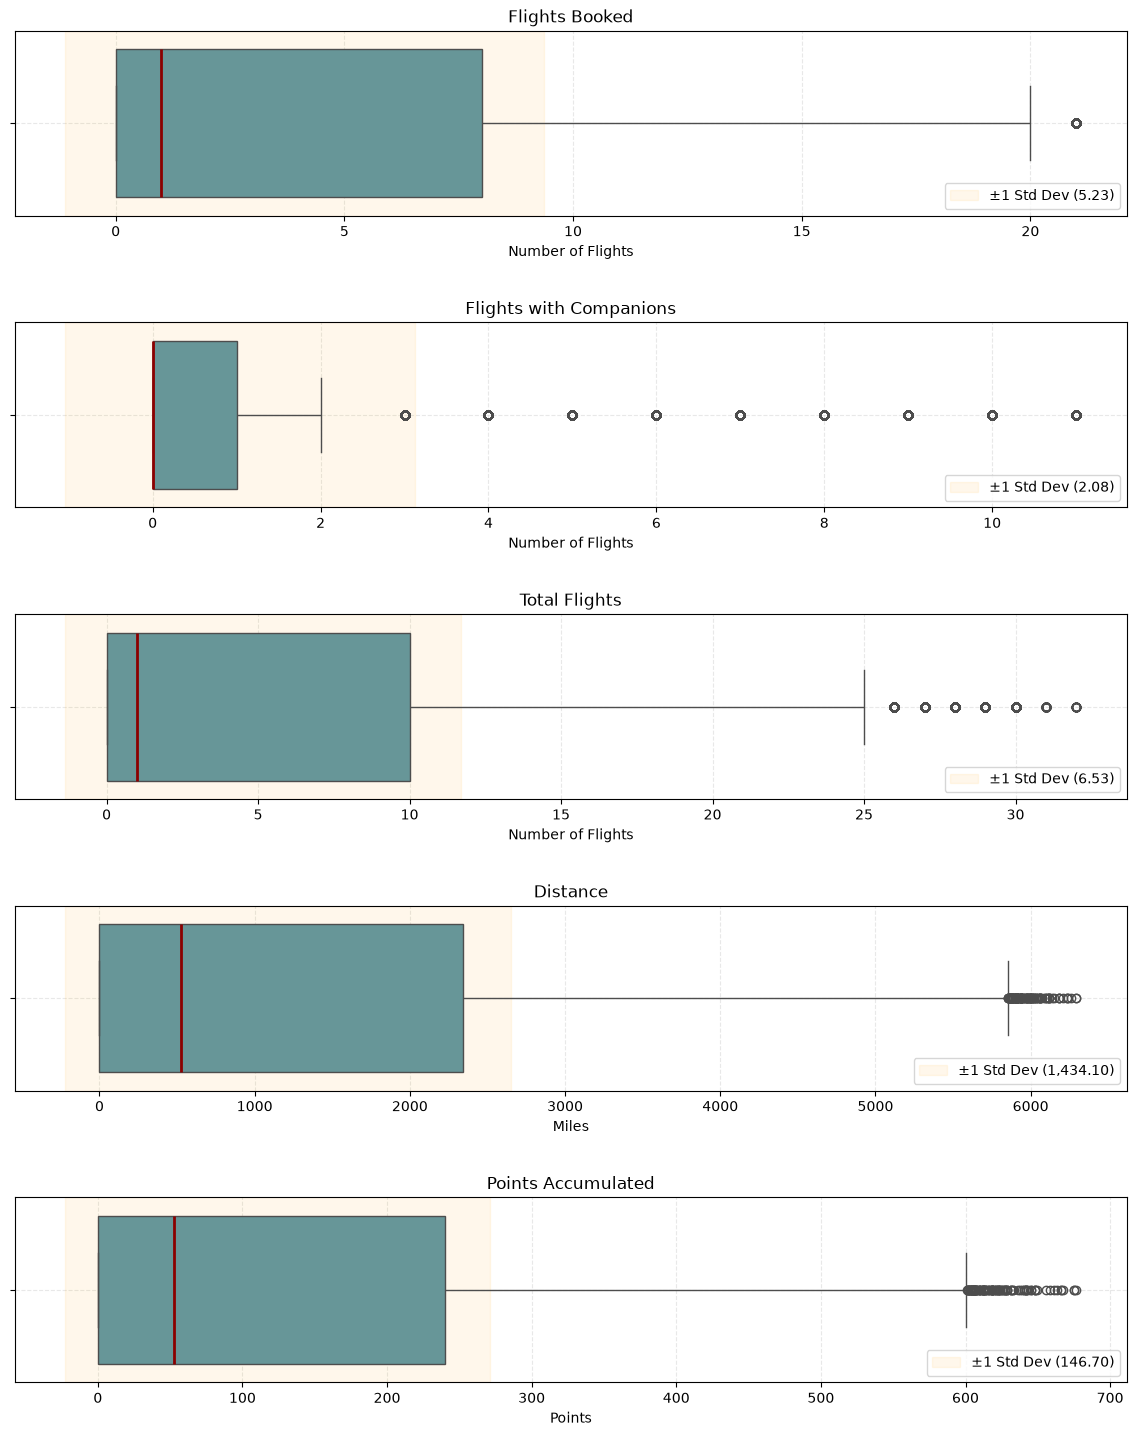

In [13]:
# Define the columns and the grid size
cols = numerical_cols_flights
nrows, ncols = 5, 1

# Create the grid layout using Matplotlib
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(12, 15))
axes = axes.flatten()  # Flatten to iterate easily

# Define clean custom units for the X-axis
units = {
    'Flights Booked': 'Number of Flights',
    'Flights with Companions': 'Number of Flights',
    'Total Flights': 'Number of Flights',
    'Distance': 'Miles',
    'Points Accumulated': 'Points'
}

# Loop through each column and plot its independent boxplot
for i, col in enumerate(cols):
    ax = axes[i]
    
    # Plot the boxplot directly on the specific axes
    sns.boxplot(
    data=df_clean,
    x=col,
    ax=ax,
    color='cadetblue',
    medianprops=dict(color='darkred', linewidth=2)
)
    # Extract statistical metrics from pre-calculated variables
    mean = sumary_df_clean.loc[col, 'mean']
    std = sumary_df_clean.loc[col, 'std']

    # Add a shaded background for ±1 Standard Deviation around the mean
    ax.axvspan(mean - std, mean + std, color='orange', alpha=0.08, 
               label=f'±1 Std Dev ({std:,.2f})')

    # Customize the individual subplot
    ax.set_title(col, fontsize=12)
    ax.set_xlabel(units.get(col, 'Values'))
    ax.set_ylabel('')
    
    # Add a subtle grid
    ax.grid(True, linestyle='--', alpha=0.5, color='lightgray', zorder=0)
    ax.set_axisbelow(True)

    ax.legend(loc='lower right')

# Hide any unused subplots
for j in range(len(cols), len(axes)):
    fig.delaxes(axes[j])

# Adjust spacing perfectly
plt.tight_layout(pad=3.0)

# Save the complete figure
plt.savefig("../figures/02_Statistical_Analysis_Figures/boxplots_outliers_flights.png")

In [14]:
# Execute the outlier detection function on the customer-related numerical columns
customers_outliers = count_outliers(df_unique_customers, numerical_cols_customers)

# Print the results in a clean, formatted table
print("Outlier Count per Variable:")
print("-" * 30)
for column, count in customers_outliers.items():
    print(f"{column:<25} : {count:>6} outliers")

Outlier Count per Variable:
------------------------------
Salary                    :    866 outliers
CLV                       :   1485 outliers


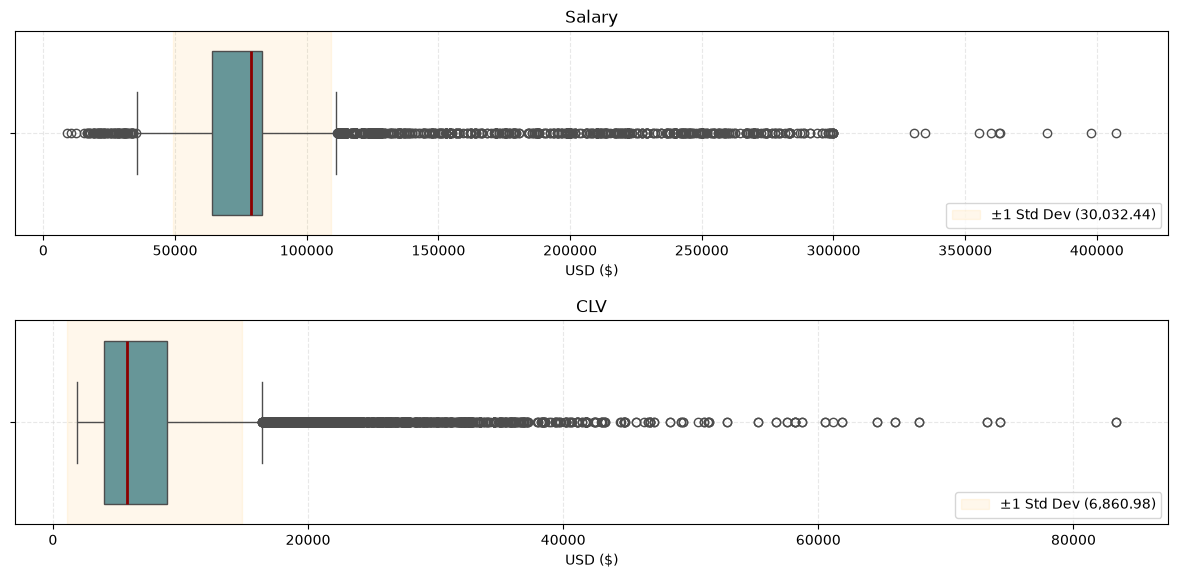

In [15]:
# Define the columns and the grid size
cols = numerical_cols_customers
nrows, ncols = 2,1

# Create the grid layout using Matplotlib
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(12, 6))
axes = axes.flatten()  # Flatten to iterate easily

# Define clean custom units for the X-axis
units = {
    'Salary': 'USD ($)',
    'CLV': 'USD ($)'
}

# Loop through each column and plot its independent boxplot
for i, col in enumerate(cols):
    ax = axes[i]

    # Extract statistical metrics from pre-calculated variables
    mean = sumary_df_customers.loc[col, 'mean']
    std = sumary_df_customers.loc[col, 'std']
    
    # Plot the boxplot directly on the specific axes
    sns.boxplot(
    data=df_unique_customers,
    x=col,
    ax=ax,
    color='cadetblue',
    medianprops=dict(color='darkred', linewidth=2)
)
    
    # Add a shaded background for ±1 Standard Deviation around the mean
    ax.axvspan(mean - std, mean + std, color='orange', alpha=0.08, 
               label=f'±1 Std Dev ({std:,.2f})')

    # Customize the individual subplot
    ax.set_title(col, fontsize=12)
    ax.set_xlabel(units.get(col, 'Values'))
    ax.set_ylabel('')
    
    # Add a subtle grid
    ax.grid(True, linestyle='--', alpha=0.5, color='lightgray', zorder=0)
    ax.set_axisbelow(True)
    
    ax.legend(loc='lower right')

# Hide any unused subplots
for j in range(len(cols), len(axes)):
    fig.delaxes(axes[j])

# Adjust spacing perfectly
plt.tight_layout(pad=1.5)

# Save the complete figure
plt.savefig("../figures/02_Statistical_Analysis_Figures/boxplots_outliers_customers.png")

***Outlier Analysis and Detection:***

* **General Overview:** Outliers are present across all studied numerical variables. The column with the lowest number of extreme values is `Points Accumulated` (112), while the highest is `Flights with Companions` (71,560).

* **Flights with Companions:** This massive count highlights that, as shown by the 75th percentile (1.00), traveling with companions is quite rare. The statistical threshold sets the upper limit at 2.5, meaning that while making 1 or 2 companion flights is considered standard behavior, **any record with 3 or more companions is immediately flagged as an outlier**.

* **Total Flights:** The outlier count drops significantly to 1,984 records. This still indicates that a high frequency of monthly trips is uncommon and stands out from the baseline behavior of regular passengers.

* **Salary vs. Customer Lifetime Value (CLV):** There is a small group of unique customers with high salaries that fall well outside the normal range, confirming the presence of an affluent segment. Interestingly, this outlier count significantly increases for `CLV`. This proves that a high income is **not the only factor that makes a customer valuable to the airline**; engagement, distance flown, and loyalty play a massive role in driving up a customer's commercial worth.

* **Visual Insights from Boxplots:** The distribution confirms that all flight-related variables (`Flights Booked`, `Flights with Companions`, `Total Flights`, `Distance`, and `Points Accumulated`) are heavily right-skewed, with the main data block compressed near zero and a long sequence of outliers on the higher end. Interestingly, the `Salary` boxplot reveals the presence of **lower-bound outliers** (atypically low incomes), showing that the program also retains a segment of **low-earning users** who deviate from the standard middle-class core. Finally, the structure of the `CLV` boxplot visually mirrors the flight activity and distance charts, **so it would be interesting study the posible correlation between active flying behavior and overall customer lifetime value**.

### Correlation Analysis:

- Examine the relationships and correlation between numerical variables.

**Correlation Analysis Note:** 

For correlation calculations, the original dataset's values for `Salary` and `CLV` were utilized. In this specific context, the objective is to analyze how these variables relate to flight-activity metrics; therefore, retaining the full longitudinal record is methodologically appropriate.

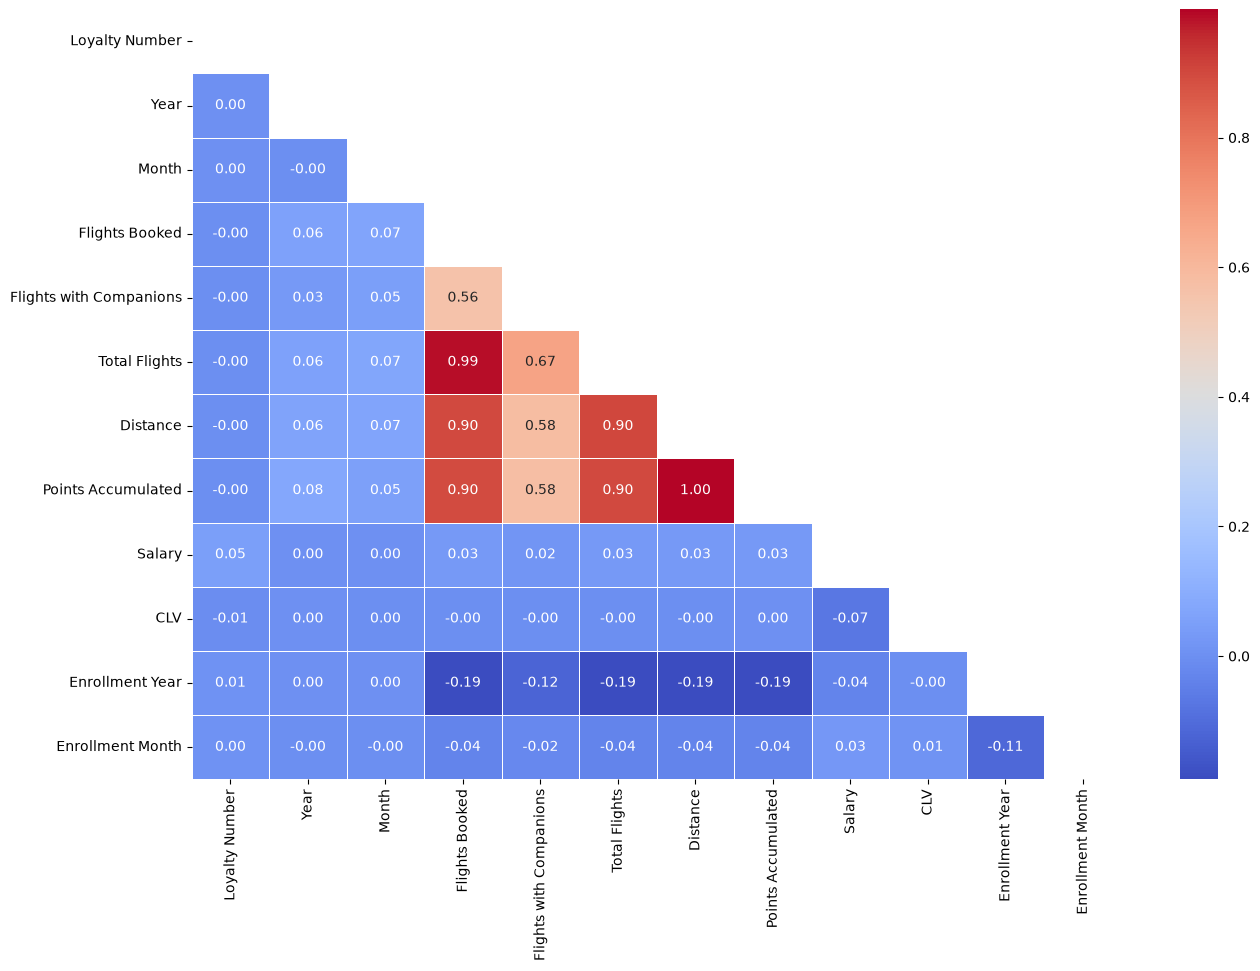

In [16]:
# Compute the Spearman rank correlation matrix for all numerical columns
matrix = df_clean.select_dtypes(include='number').corr(method='spearman')

# Generate a mask for the upper triangle to hide redundant mirror values
mask = np.triu(np.ones_like(matrix, dtype=bool)) 

# Generate the figure
plt.figure(figsize= (15, 10))
sns.heatmap(matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5, mask=mask) 

# Save the complete figure
plt.savefig("../figures/02_Statistical_Analysis_Figures/heatmap.png")

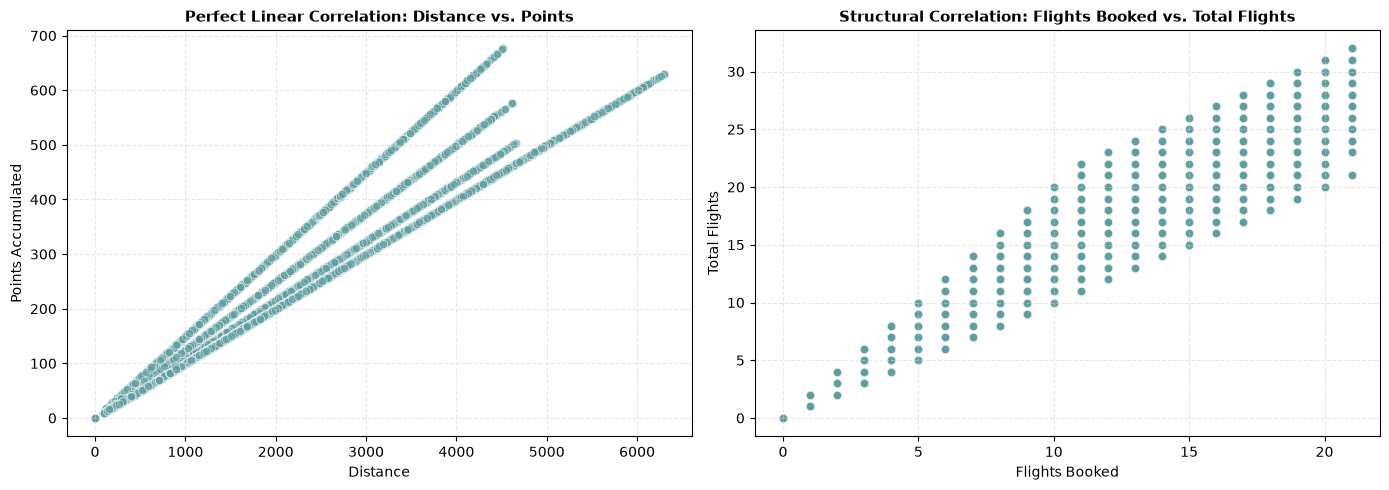

In [17]:
# Create a figure for the key correlation insights
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))

# Scatter plot for Distance vs Points Accumulated
sns.scatterplot(
    data=df_clean, 
    x='Distance', 
    y='Points Accumulated', 
    ax=axes[0], 
    color='cadetblue', 
    alpha=0.6
)
axes[0].set_title('Perfect Linear Correlation: Distance vs. Points', fontsize=11, fontweight='bold')
axes[0].grid(True, linestyle='--', alpha=0.5, color='lightgray')

# Scatter plot for Flights Booked vs Total Flights
sns.scatterplot(
    data=df_clean, 
    x='Flights Booked', 
    y='Total Flights', 
    ax=axes[1], 
    color='cadetblue', 
    alpha=0.6
)
axes[1].set_title('Structural Correlation: Flights Booked vs. Total Flights', fontsize=11, fontweight='bold')
axes[1].grid(True, linestyle='--', alpha=0.5, color='lightgray')


plt.tight_layout()
plt.savefig("../figures/02_Statistical_Analysis_Figures/key_correlations.png", dpi=300)

***Spearman Correlation Analysis Insights:***

* **Flight Activity and Loyalty Rewards:** There is a perfect positive linear correlation (**1.00**) between `Distance` and `Points Accumulated`. This confirms that the airline's loyalty reward program functions strictly as a direct linear function of the total distance flown by the passenger.
* **Structural Dependency:** `Total Flights` shows an almost perfect correlation with `Flights Booked` (**0.99**) and a strong correlation with `Flights with Companions` (**0.67**). This is expected since total monthly flights are structurally composed of these two sub-metrics.
* **Business Metrics Isolation (`CLV` and `Salary`):** Interestingly, `CLV` and `Salary` show virtually **zero correlation** with flight frequency, distance, or tracking timelines (coefficients fluctuate between -0.07 and 0.05). This implies that a customer's total calculated lifetime value or salary level does not dictate their monthly flight volume under this program. Methodologically, this suggests that `CLV` acts as a predictive estimation of a customer's potential value, heavily weighted by other structural dimensions rather than raw trip counts—such as demographic profiles, loyalty card tiers, and historical enrollment tenure.

## 02. Categorical Variable Analysis

### Frequency Analysis:

- Distribution of relevant categorical variables

**Methodological Note:** The categorical variables were analyzed using the combined dataset (`df_clean`). By adopting this approach, the variables are examined within the comprehensive context of overall flight activity rather than being strictly limited to unique customer profiles, ensuring a more accurate representation of transactional behaviors.

In [18]:
def compute_frequency_table (df, col):
    absolute_frequency = df[col].value_counts()
    relative_frequency = round(df[col].value_counts(normalize=True)*100,2)

    frequency_table= pd.DataFrame({
        col: absolute_frequency.index,
        'absolute_frequency' :  absolute_frequency.values,
        'relative_frequency' : relative_frequency.values,
    })
    
    return frequency_table.set_index(col)


In [19]:
province_table = compute_frequency_table(df_clean, 'Province')
province_table

,absolute_frequency,relative_frequency
Province,,
Ontario,130258,32.26
British Columbia,106442,26.36
Quebec,79573,19.71
Alberta,23360,5.79
Manitoba,15900,3.94
New Brunswick,15352,3.80
Nova Scotia,12507,3.10
Saskatchewan,9861,2.44
Newfoundland,6244,1.55


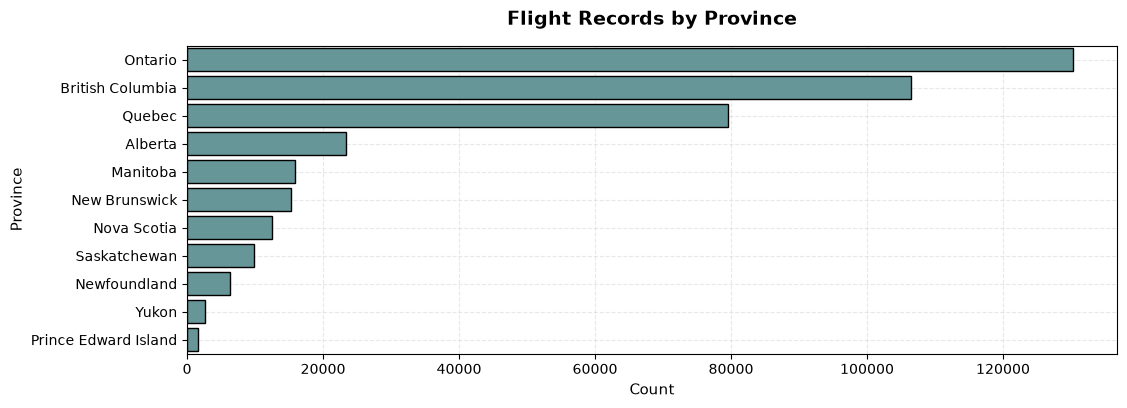

In [20]:
# Set up the figure dimensions for a wide categorical plot
plt.figure(figsize=(12, 4))

# Plot the ordered countplot with custom styling
sns.countplot(
    data=df_clean,
    y='Province',
    color='cadetblue',
    edgecolor='black',
    orient= 'h',
    linewidth=1,
    order=df_clean['Province'].value_counts().index  # Automatically orders from highest to lowest
)

# Customize titles and axes labels in English
plt.title('Flight Records by Province', fontsize=14, pad=15, fontweight='bold')
plt.ylabel('Province', fontsize=11)
plt.xlabel('Count', fontsize=11)


# Apply clean grid behind the bars
plt.grid(True, linestyle='--', alpha=0.5, color='lightgray', zorder=0)
plt.gca().set_axisbelow(True)  # Keeps the grid lines behind the bars

plt.savefig("../figures/02_Statistical_Analysis_Figures/Flight_Records_by_Province.png", dpi=300)

**Insight:** The vast majority of flights are taken by customers residing in **Ontario, British Columbia, and Quebec**, which combined account for **78.33%** of the total volume. In contrast, the remaining eight provinces represent a minor share, making up only **21.67%** of the distribution.

In [21]:
gender_table = compute_frequency_table(df_clean, 'Gender')
gender_table

,absolute_frequency,relative_frequency
Gender,,
Female,202757,50.22
Male,201003,49.78


**Insight:** The distribution shows nearly perfect gender parity among customers, with an almost identical and even split between females (**50.22%**) and males (**49.78%**).

In [22]:
education_table = compute_frequency_table(df_clean, 'Education')
education_table

,absolute_frequency,relative_frequency
Education,,
Bachelor,252567,62.55
College,102260,25.33
High School or Below,18915,4.68
Doctor,17731,4.39
Master,12287,3.04


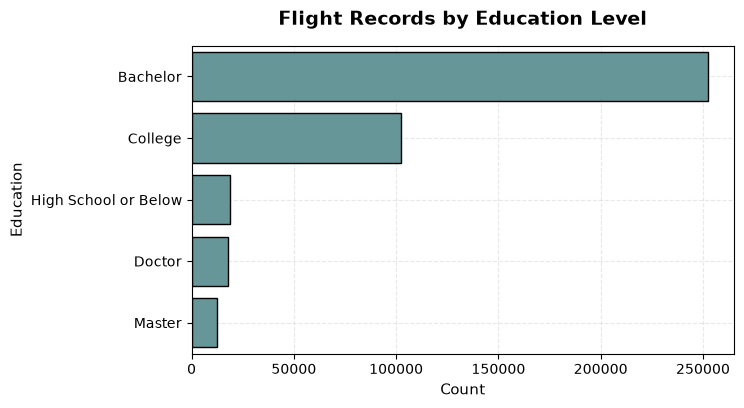

In [23]:
# Set up the figure dimensions for a wide categorical plot
plt.figure(figsize=(7, 4))

# Plot the ordered countplot with custom styling
sns.countplot(
    data=df_clean,
    y='Education',
    color='cadetblue',
    edgecolor='black',
    orient= 'h',
    linewidth=1,
    order=df_clean['Education'].value_counts().index  # Automatically orders from highest to lowest
)

# Customize titles and axes labels in English
plt.title('Flight Records by Education Level', fontsize=14, pad=15, fontweight='bold')
plt.ylabel('Education', fontsize=11)
plt.xlabel('Count', fontsize=11)


# Apply clean grid behind the bars
plt.grid(True, linestyle='--', alpha=0.5, color='lightgray', zorder=0)
plt.gca().set_axisbelow(True)  # Keeps the grid lines behind the bars

plt.savefig("../figures/02_Statistical_Analysis_Figures/Flight_Records_by_Education_Level.png", dpi=300)

**Insight:** The vast majority of flights are generated by individuals with a **Bachelor** or **College** education, combined representing **87.88%** of the total. This aligns perfectly with macroeconomic and social realities, where advanced postgraduate degrees—such as a **Master** or **Doctorate**—are inherently held by a much smaller segment of the general population compared to undergraduate or college-level studies.

In [24]:
marital_table = compute_frequency_table(df_clean, 'Marital Status')
marital_table

,absolute_frequency,relative_frequency
Marital Status,,
Married,234845,58.16
Single,108153,26.79
Divorced,60762,15.05


**Insight:** Over half of the recorded flights (**58.16%**) are taken by **Married** customers. This is a particularly interesting finding when contrasted with the previous analysis, which showed a low volume of companion flights (`Flights with Companions`). This suggests that despite being married, these customers frequently travel alone, potentially indicating a **high volume of solo business travel**.

In [25]:
loyalty_table = compute_frequency_table(df_clean, 'Loyalty Card')
loyalty_table

,absolute_frequency,relative_frequency
Loyalty Card,,
Star,183745,45.51
Nova,136883,33.90
Aurora,83132,20.59


**Insight:** The distribution of loyalty card tiers follows a classic and healthy customer pyramid structure. The entry-level **Star** tier holds the largest share at **45.51%**, followed by the mid-tier **Nova** at **33.90%**. Notably, the premium **Aurora** tier accounts for a substantial **20.59%** of the total volume. Having one-fifth of the customer base in the highest loyalty tier represents a strong, highly engaged core segment for the airline.